# VISION on the Visium mouse colon dataset

This notebook demonstrates a standard, standalone VISION pipeline (gene signature scoring and graph autocorrelation) using `scviva.tools.vision.VisionAnalysis`.

**Dataset:** the same mouse colon 10x Visium dataset (Parigi et al.) used in [`Visium_colon_Harreman_pipeline`](Visium_colon_Harreman_pipeline.ipynb), loaded via `load_visium_mouse_colon_dataset()`. For how VISION and Harreman's Hotspot-equivalent gene modules intersect on this same dataset, see that other tutorial.

**Gene signatures:** KEGG metabolic pathway gene sets, fetched from the same hosted URL (`exampledata.scverse.org`) used in that other tutorial.

**Pipeline:**
1. Load the dataset and apply minimal per-sample gene filtering.
2. `VisionAnalysis.setup(compute_neighbors_on_key="spatial_unrolled")` — VISION builds and owns its own spot neighbor graph from the (unrolled) spatial coordinates.
3. `va.load_signatures()` / `va.compute_signatures()` — score every spot against the KEGG pathways and test each pathway's spatial autocorrelation.
4. `va.compute_differential_expression()` — test which pathways differ most between the two regeneration timepoints (Day 0 vs Day 14).
5. Spatial visualization of the most autocorrelated KEGG pathway.
6. An alternative, expression-embedding-based workflow (`filter_genes`/`compute_latent_space`/`generate_projections`/`pool_cells`).

## 0 · Imports

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import requests
import scanpy as sc

from scviva.tools.harreman.datasets import load_visium_mouse_colon_dataset
from scviva.tools.vision import VisionAnalysis

print("Imports OK")

Imports OK


## 1 · Load the Visium mouse colon dataset

In [2]:
adata = load_visium_mouse_colon_dataset()
print(adata)

AnnData object with n_obs × n_vars = 6168 × 31053
    obs: 'in_tissue', 'array_row', 'array_col', 'cond', 'id', 'row', 'col', 'layer', 'ord', 'dist', 'spot', 'pixel_x', 'pixel_y'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cond_colors'
    obsm: 'spatial', 'spatial_unrolled'
    layers: 'counts', 'log_norm', 'normalized'


In [3]:
# Minimal per-sample gene filtering: keep a gene if it passes the expression
# threshold in ANY sample (union across "cond" == "Day 0"/"Day 14"), matching
# the preprocessing in Visium_colon_Harreman_pipeline.ipynb.
sample_col = "cond"
n_genes_expr = 50
genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

for sample in adata.obs[sample_col].unique():
    adata_sample = adata[adata.obs[sample_col] == sample]
    expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
    genes_to_keep |= expressed >= n_genes_expr

adata = adata[:, genes_to_keep].copy()

# Drop obs columns that are purely technical bookkeeping (array/pixel
# coordinates, per-spot barcodes, a QC flag that's constant after filtering to
# in-tissue spots) so the VISION differential-expression step below only
# compares signatures across the biologically meaningful metadata: "cond"
# (regeneration day), "layer", "ord" and "dist" (spatial axes).
adata.obs = adata.obs.drop(
    columns=["in_tissue", "array_row", "array_col", "id", "row", "col", "spot", "pixel_x", "pixel_y"]
)
print(adata)

AnnData object with n_obs × n_vars = 6168 × 13967
    obs: 'cond', 'layer', 'ord', 'dist'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'cond_colors'
    obsm: 'spatial', 'spatial_unrolled'
    layers: 'counts', 'log_norm', 'normalized'


## 2 · VISION setup: spatial neighbor graph

`VisionAnalysis.setup()` builds and owns its own KNN graph directly from `compute_neighbors_on_key="spatial_unrolled"` (Parigi et al.'s common linear coordinate across conditions).


In [4]:
va = VisionAnalysis(adata, norm_data_key="log_norm")
va.setup(compute_neighbors_on_key="spatial_unrolled", num_neighbors=5)
print(f"obsp['weights'] shape: {adata.obsp['weights'].shape}, nnz: {adata.obsp['weights'].nnz}")

INFO     Building KNN graph: n_cells=6168, K=5.                                                                    
INFO     KNN weight matrix built — nnz=30840.                                                                      
INFO     KNN weights stored in adata.obsp['weights'] — shape (6168, 6168).                                         
INFO     VisionAnalysis: setup complete.                                                                           
obsp['weights'] shape: (6168, 6168), nnz: 30840


## 3 · Tissue sections at a glance

A quick look at the two conditions (regeneration Day 0 vs Day 14) across the
unrolled tissue before diving into signature analysis.


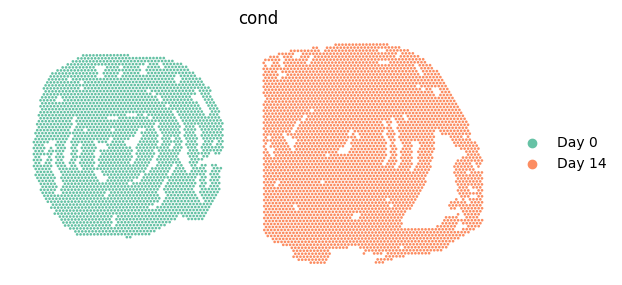

In [5]:
sc.pl.spatial(adata, color="cond", spot_size=80, frameon=False)

## 4 · Load KEGG metabolic signatures and score them (`va`)

Gene signatures here are KEGG metabolic pathway gene sets, fetched from the same hosted URL as `Visium_colon_Harreman_pipeline.ipynb`. `compute_signatures()` both scores every spot against each pathway and tests each pathway's autocorrelation against the neighbor graph built in step 2.

In [6]:
resp = requests.get("https://exampledata.scverse.org/scvi-tools/KEGG_metab_m.json")
resp.raise_for_status()
kegg_metab = resp.json()
print(f"KEGG metabolic pathways available: {len(kegg_metab)}")

va.load_signatures(dicts=[kegg_metab], min_signature_genes=5, sig_gene_threshold=0.001)
print(f"signatures loaded: {adata.varm['signatures'].shape[1]}")

va.compute_signatures()
print(f"vision_signatures: {adata.obsm['vision_signatures'].shape}")

autocorr_sig = adata.uns["vision_signature_scores"].sort_values("c_prime", ascending=False)
print("\nTop 10 most autocorrelated KEGG pathways:")
print(autocorr_sig.head(10).round(4).to_string())

KEGG metabolic pathways available: 69
signatures loaded: 69
INFO     Computing signatures for each cell...                                                                     
WARNING  PyTorch path failed (The NVIDIA driver on your system is too old (found version 12020). Please update your
         GPU driver by downloading and installing a new version from the URL:                                      
         http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch  
         version that has been compiled with your version of the CUDA driver.); falling back to scipy sparse.      
INFO     Signatures computed in 3.368 s.                                                                           
INFO     Computing Geary's C for all the signatures...                                                             
INFO     Generating the null distribution...                                                                       
INFO     Com

## 5 · Differential expression: Day 0 vs Day 14

`compute_differential_expression()` runs a one-vs-all comparison of every KEGG pathway score across each categorical `adata.obs` column: here `"cond"` (condition; Day 0 or Day 14) is the only one left after the column pruning in step 1.

In [7]:
va.compute_differential_expression()

cond_diff = adata.uns["vision_signature_differential"]["cond"]
for group, df in cond_diff.groupby("group"):
    top = df.sort_values("scores", ascending=False).head(5)
    print(f"\nTop 5 KEGG pathways up in {group} (vs rest):")
    print(top[["names", "scores", "pvals_adj"]].to_string(index=False))

INFO     Computing observation scores...                                                                           
INFO     Finished computing observation scores in 5.624 seconds.                                                   

Top 5 KEGG pathways up in Day 0 (vs rest):
                     names   scores    pvals_adj
       PYRUVATE METABOLISM 1.007384 1.047618e-86
   CITRATE CYCLE TCA CYCLE 1.000767 2.351702e-79
GLYCOLYSIS GLUCONEOGENESIS 0.999726 2.510121e-78
        LYSINE DEGRADATION 0.999376 4.879073e-78
     PROPANOATE METABOLISM 0.988209 2.236010e-66

Top 5 KEGG pathways up in Day 14 (vs rest):
                          names   scores     pvals_adj
    ARACHIDONIC ACID METABOLISM 1.392401 9.444190e-150
         GLUTATHIONE METABOLISM 1.332283  1.242395e-72
       LINOLEIC ACID METABOLISM 1.323479  1.027541e-63
ALPHA LINOLENIC ACID METABOLISM 1.276671  5.119237e-26
          O GLYCAN BIOSYNTHESIS 1.275597  2.239545e-25


## 6 · Spatial visualization of the top autocorrelated pathway

Rather than assume a specific expected biological pattern up front, we let the data pick the most spatially-autocorrelated KEGG pathway from the analysis above and plot it directly across the tissue.

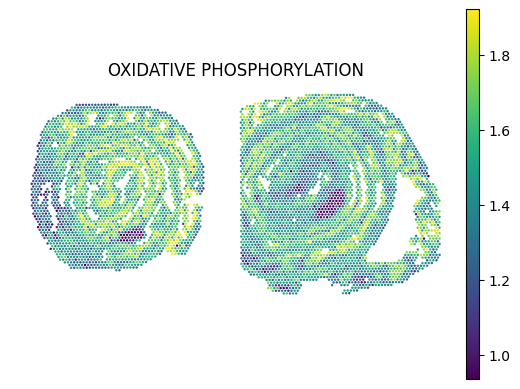

In [8]:
top_sig = autocorr_sig.index[0]
adata.obs["top_kegg_pathway_score"] = adata.obsm["vision_signatures"][top_sig].values

sc.pl.spatial(
    adata,
    color="top_kegg_pathway_score",
    spot_size=80,
    frameon=False,
    vmin="p1",
    vmax="p99",
    cmap="viridis",
    title=top_sig,
)

## 7 · Alternative embedding-based workflow

Everything above built VISION's neighbor graph directly from the tissue's physical (unrolled) coordinates. VISION can equally build its graph from an **unsupervised expression embedding** instead. This section runs a fresh `VisionAnalysis` session on a copy of `adata` (so it doesn't disturb the spatial `obsp["weights"]` graph the sections above rely on) to exercise `filter_genes()`, `compute_latent_space()`, `generate_projections()`, and `pool_cells()` (the parts of the VISION API the sections above don't touch).

**Note on PhyloVision:** VISION also supports building its neighbor graph from a phylogenetic tree (`va.setup(tree=...)`), lineage-plasticity scoring (`va.tl.compute_plasticity_scores`), and tree-based clustering (`va.tl.cluster_cells_tree`). That mode needs lineage-tree data this Visium dataset doesn't have, so it isn't demonstrated here (see the `scviva.tools.vision.phylo` API reference).


In [ ]:
adata_pca = adata.copy()
va2 = VisionAnalysis(adata_pca, norm_data_key="log_norm")

mask = va2.filter_genes(filters=("threshold", "fano"))
print(f"filter_genes: {mask.sum()} / {len(mask)} genes pass threshold+fano filtering")
# compute_latent_space() below applies this same filtering internally before PCA.

va2.compute_latent_space()
print(f"X_pca: {adata_pca.obsm['X_pca'].shape}")

va2.setup(compute_neighbors_on_key="X_pca")
va2.generate_projections(methods=["UMAP"])
print(f"X_UMAP: {adata_pca.obsm['X_UMAP'].shape}")

va2.pool_cells(cells_per_partition=20)
pools = adata_pca.uns["micro_clusters"]
print(f"pool_cells: {len(pools)} micro-clusters pooling {adata_pca.n_obs} spots")

INFO     Threshold filter (min 10 cells): 13967 / 13967 genes retained.                                            


INFO     Threshold filter (min 10 cells): 13967 / 13967 genes retained.                                            


INFO     Fano filter (2.0 MADs, 30 bins): 2672 / 13967 genes retained.                                             


INFO     apply_filters(['threshold', 'fano']): 2672 / 13967 genes retained.                                        


filter_genes: 2672 / 13967 genes pass threshold+fano filtering
INFO     Computing latent space for expression data...                                                             


...

INFO     Fano filter (2.0 MADs, 30 bins): 2401 / 13967 genes retained.                                             


INFO     apply_filters(['threshold', 'fano']): 2401 / 13967 genes retained.                                        


INFO     Louvain micro-clustering: n_cells=6168, K=30, target ~20 cells/partition.                                 


INFO     Micro-clustering complete: 308 micro-clusters.                                                            


pool_cells: 308 micro-clusters pooling 6168 spots


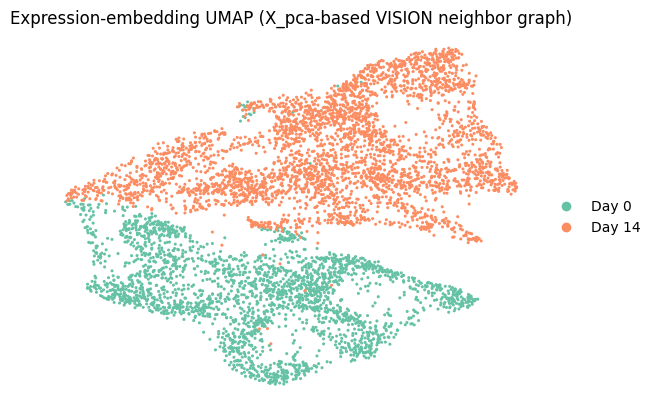

In [ ]:
sc.pl.embedding(
    adata_pca,
    basis="X_UMAP",
    color="cond",
    frameon=False,
    title="Expression-embedding UMAP (X_pca-based VISION neighbor graph)",
)

## 8 · Reusing already-loaded signatures (`attach_signatures`)

`load_signatures()` (section 4) both parses a GMT/dict source *and* stores the result in `adata.varm`. If signatures were already loaded (by an earlier `VisionAnalysis` session on the same `adata`, or by calling `scviva.tools.vision.tools.signature.load_signatures` directly) re-parsing the source is redundant. `attach_signatures()` just points a new session at the existing `adata.varm` entry. Here we use it to re-score the same KEGG pathways against a *different* expression layer (`"normalized"` instead of `"log_norm"`) without re-fetching or re-parsing the KEGG gene sets.

In [9]:
va_reuse = VisionAnalysis(adata, norm_data_key="normalized")
va_reuse.setup(compute_neighbors_on_key="spatial_unrolled", num_neighbors=5)
va_reuse.attach_signatures()  # reuses the "signatures" `va` already loaded from KEGG
va_reuse.compute_signatures()  # overwrites adata's vision_signatures/vision_signature_scores

autocorr_reuse = adata.uns["vision_signature_scores"].sort_values("c_prime", ascending=False)
print("Top 5 KEGG pathways when scored on the 'normalized' layer instead of 'log_norm':")
print(autocorr_reuse.head(5).round(4).to_string())

INFO     Building KNN graph: n_cells=6168, K=5.                                                                    


INFO     KNN weight matrix built — nnz=30840.                                                                      
INFO     KNN weights stored in adata.obsp['weights'] — shape (6168, 6168).                                         
INFO     VisionAnalysis: setup complete.                                                                           
INFO     Computing signatures for each cell...                                                                     
WARNING  PyTorch path failed (The NVIDIA driver on your system is too old (found version 12020). Please update your
         GPU driver by downloading and installing a new version from the URL:                                      
         http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch  
         version that has been compiled with your version of the CUDA driver.); falling back to scipy sparse.      
INFO     Signatures computed in 1.284 s.                                

## 9 · Direct one-vs-one gene differential expression (`compute_one_vs_one_de`)

`compute_differential_expression()` (section 5) tested *signatures*
one-vs-all across `"cond"`. `compute_one_vs_one_de()` complements it at the
*gene* level: a direct Wilcoxon test of every gene between two named groups
of an `adata.obs` column, returning a scanpy-style results `DataFrame`
rather than writing into `adata.uns`.


In [10]:
de_day0_vs_day14 = va.compute_one_vs_one_de(key="cond", group1="Day 0", group2="Day 14")
print("Top genes up in Day 0 vs. Day 14 (one-vs-one Wilcoxon):")
print(de_day0_vs_day14.sort_values("scores", ascending=False).head(5).to_string(index=False))

Top genes up in Day 0 vs. Day 14 (one-vs-one Wilcoxon):
 names   scores  logfoldchanges  pvals  pvals_adj
 Mptx1 1.278292        2.802165    0.0        0.0
  Igha 1.274261        2.082730    0.0        0.0
  Igkc 1.208995        1.251213    0.0        0.0
Jchain 1.206805        1.742756    0.0        0.0
 Neat1 1.151869        0.786609    0.0        0.0


## 10 · Inspecting a signature's genes and their expression

`get_genes_by_signature()` lists the genes making up a signature (with
their +/-1 sign), and `get_gene_expression()` pulls dense per-cell
expression for arbitrary genes from whichever layer the session is scoring
from. Together they let you drill from "this pathway is spatially
autocorrelated" (section 4/6) down to the individual genes driving it.


In [11]:
top_sig_genes = va.get_genes_by_signature(top_sig)
print(f"'{top_sig}' has {len(top_sig_genes)} genes:")
print(top_sig_genes.head(10))

expr = va.get_gene_expression(top_sig_genes.index[:3].tolist())
print(f"\nDense expression for the top 3 genes, shape: {expr.shape}")

'OXIDATIVE PHOSPHORYLATION' has 100 genes:
           0
Atp6v1h  1.0
Cox5b    1.0
Ndufb3   1.0
Ndufs1   1.0
Ndufa10  1.0
Sdhc     1.0
Ndufs2   1.0
Ndufa8   1.0
Ndufs3   1.0
Cox4i2   1.0

Dense expression for the top 3 genes, shape: (6168, 3)


## 11 · The lower-level `rank_genes_groups` function

`compute_one_vs_one_de()` (section 10) and `compute_differential_expression()` (section 5) both wrap `scviva.tools.vision.rank_genes_groups` (VISION's own Wilcoxon rank-sum implementation; extended from scanpy's to also report AUC). It's lazily imported (not eagerly pulled in when you `import scviva.tools.vision`) so it's available as a standalone function when you want gene-level one-vs-rest DE without a `VisionAnalysis` session at all.

In [12]:
from scviva.tools.vision import rank_genes_groups

rank_genes_groups(
    adata, groupby="cond", method="wilcoxon", layer="log_norm", use_raw=False, key_added="rank_genes_groups_cond"
)
de_all = sc.get.rank_genes_groups_df(adata, "Day 14", key="rank_genes_groups_cond")
print("Top genes up in Day 14 (one-vs-rest Wilcoxon, called directly):")
print(de_all.sort_values("scores", ascending=False).head(5).to_string(index=False))

Top genes up in Day 14 (one-vs-rest Wilcoxon, called directly):
 names   scores  logfoldchanges         pvals     pvals_adj
 Krt13 1.475519        5.989747 9.201326e-306 1.168317e-302
Tmsb10 1.473530        0.573227 1.921492e-301 2.236456e-298
Tmsb4x 1.466570        0.558383 1.431838e-286 1.333232e-283
Tmbim6 1.466198        0.610083 8.718623e-286 7.610813e-283
 Plac8 1.462923        0.798812 6.269904e-279 5.151279e-276


## 12 · Takeaways

- `VisionAnalysis(adata, norm_data_key="log_norm")` ran the full VISION pipeline standalone on the Visium mouse colon dataset used in [`Visium_colon_Harreman_pipeline`](Visium_colon_Harreman_pipeline.ipynb), from a single hosted dataset download plus a hosted KEGG gene-set file.
- `compute_differential_expression()` surfaced KEGG pathways that significantly differ between the two regeneration timepoints, purely from per-cell signature scores (no gene-module discovery step required).
- See [`Visium_colon_Harreman_pipeline`](Visium_colon_Harreman_pipeline.ipynb) for how these same VISION signatures intersect with Harreman's Hotspot-equivalent gene modules via `ha.vs.integrate_vision_hotspot_results()`.
- `filter_genes()`, `compute_latent_space()`, `generate_projections()`, and `pool_cells()` were exercised on an expression-embedding-based `VisionAnalysis` session (section 7), independent of the spatial-coordinate-based session used for the main pipeline above.
- `attach_signatures()` (section 8) re-scored the same KEGG pathways on a different expression layer without re-parsing the gene sets.
- `compute_one_vs_one_de()` (section 9) and the standalone `rank_genes_groups()` (section 11) gave direct, gene-level Wilcoxon tests independent of the signature-level differential expression in section 5.
- `get_genes_by_signature()` and `get_gene_expression()` (section 10) drilled from a signature's autocorrelation score down to its individual member genes.